In [2]:
import wandb
from collections import defaultdict
import math
from matplotlib import pyplot as plt
import numpy as np
api = wandb.Api()

In [3]:
api = wandb.Api()
runs = api.runs("huzican/div") 
for run in runs:
    if run.name in ['qwen-math7B_coef0.01','qwen-math7B_coef0.001','belu0.01_correct_clip0.2_0.28','qwen-math7B_coef1.0']:
        print(f"名称: {run.name}, ID: {run.id}")

名称: qwen-math7B_coef0.01, ID: tyfkio82
名称: qwen-math7B_coef0.001, ID: 0jzp3vqh
名称: qwen-math7B_coef1.0, ID: 1q4ixgpc
名称: belu0.01_correct_clip0.2_0.28, ID: 4eotdrrd


In [4]:
def smooth(y, radius, mode='two_sided', valid_only=False):
    assert mode in ('two_sided', 'causal')
    if len(y) < 2*radius+1:
        return np.ones_like(y) * y.mean()
    elif mode == 'two_sided':
        convkernel = np.ones(2 * radius+1)
        out = np.convolve(y, convkernel,mode='same') / np.convolve(np.ones_like(y), convkernel, mode='same')
        if valid_only:
            out[:radius] = out[-radius:] = np.nan
    elif mode == 'causal':
        convkernel = np.ones(radius)
        out = np.convolve(y, convkernel,mode='full') / np.convolve(np.ones_like(y), convkernel, mode='full')
        out = out[:-radius+1]
        if valid_only:
            out[:radius] = np.nan
    return out

In [18]:
run_names = ["huzican/div/0jzp3vqh", "huzican/div/tyfkio82", "huzican/div/4eotdrrd", "huzican/div/1q4ixgpc"]
legends = ["λ=0.001", "λ=0.01", "λ=0.1", "λ=1.0"]
# benchmarks = ["aime", "aime25", "amc", "math", "minerva", "olympiad_bench","average", "entropy","response_lenth"]
# titles = ['AIME','AIME25','AMC',"MATH500","Minerva","Olympiad","Average", "Entorpy","Response Lenth"]
run_results = {}
for idx, run_name in enumerate(run_names):
    run = api.run(run_name)
    scores = defaultdict(list)
    # print(scores)
    for i, row in run.history().iterrows():
        # print(row['val/test_score/aime'])
        # print(row['val/test_score/math'])
        # for benchmark in benchmarks:
        #     if benchmark == "entropy":
        #         path = "actor/entropy_loss"
        #     elif benchmark == "response_lenth":
        #         path = "response_length/mean"
        #     else:
            path = "val/test_score/average"
            if not math.isnan(row[path]):
                scores['average'].append(row[path])
    
    run_results[legends[idx]] = scores
    

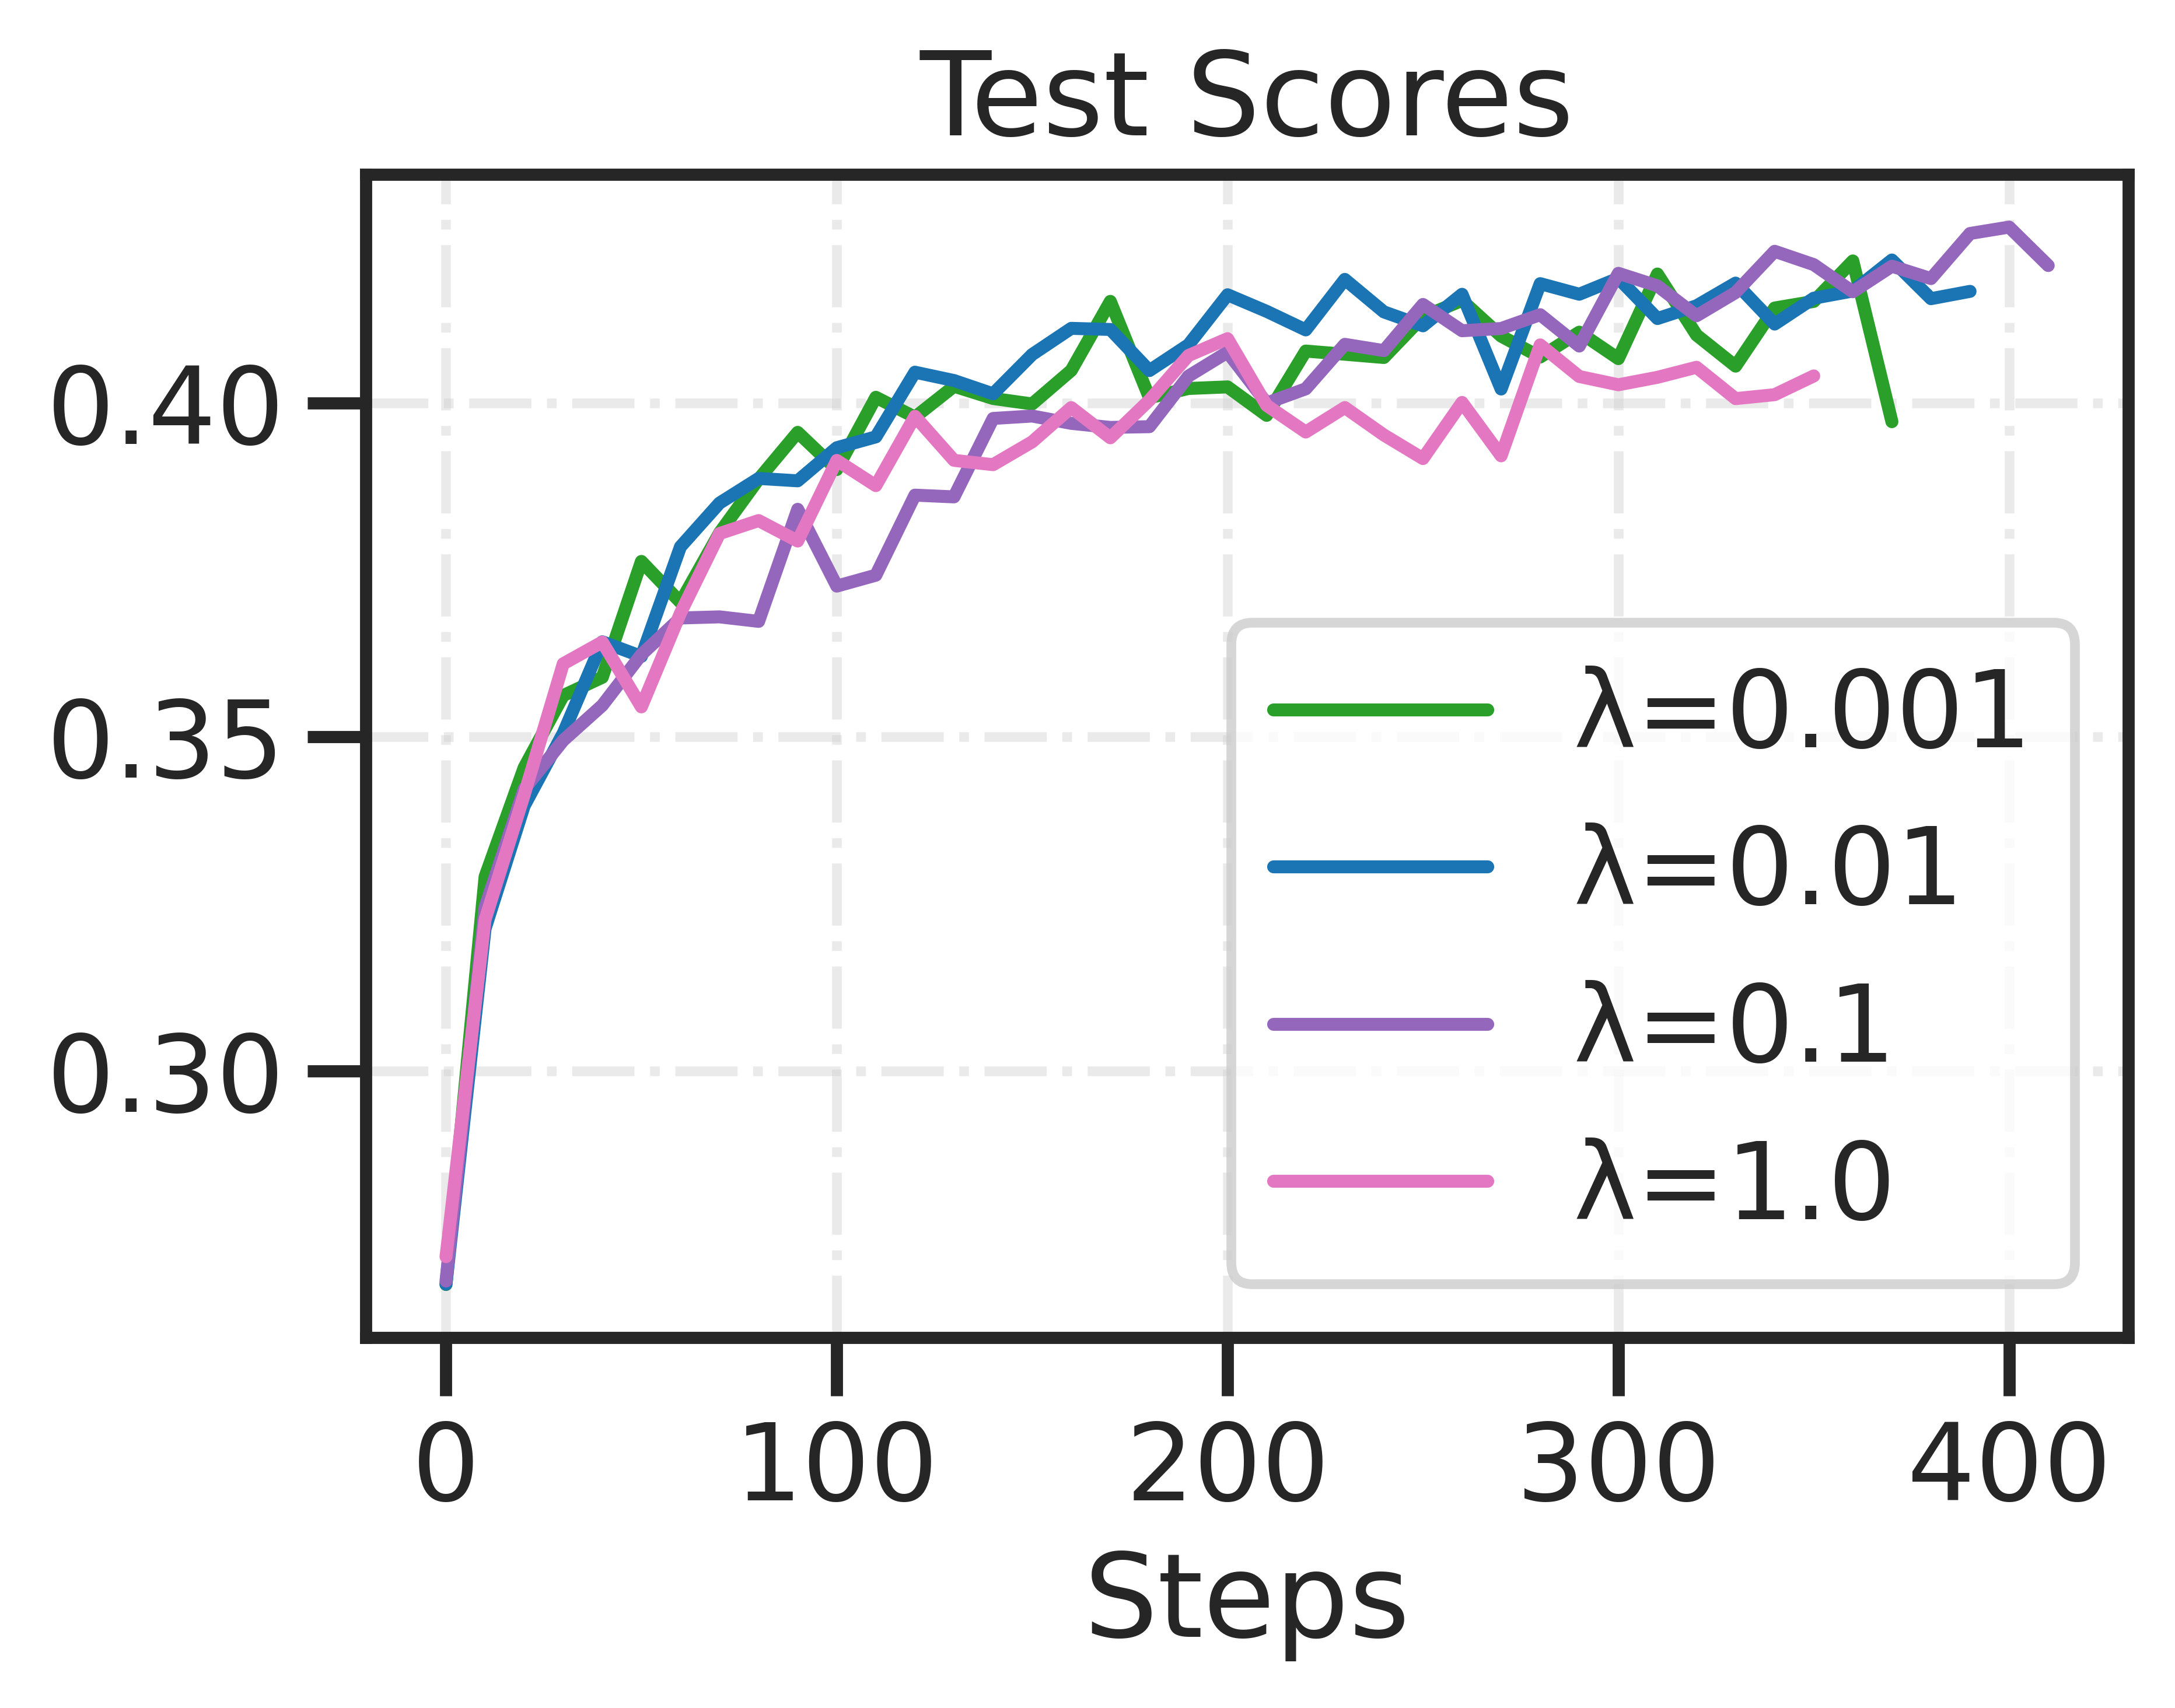

In [30]:
color = ['#2A9F2A', '#1B75B4','#9467BD','#E377C2','#7F7F7F','#FF7F0E']
# benchmarks = ["aime", "aime25", "amc", "math", "minerva", "olympiad_bench","average", "entropy"]
# # titles = ['AIME','AIME25','AMC',"MATH500","Minerva","Olympiad","Average", "Entorpy"]
# markers = ['h', 's', 'p', 'o']
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')
sns.set_context('talk')
fig=plt.figure(figsize=(5, 4),dpi=800)

plt.title('Test Scores',fontsize=18)
for index, alg in enumerate(legends):
        data = np.array(run_results[alg]['average'])
        x_step = np.array(range(data.shape[0]))*10
        ax = sns.lineplot(x=x_step, y=data.flatten(),label=legends[index], color=color[index], linewidth=2)
        # plt.plot(x_step, data, markers[index], color=color[index], markersize=8)
        # plt.yticks(np.array(range(int(np.min(data))-1, int(np.max(data))+1, 20 if metric=="solve_all" else 10)))
        plt.xticks(np.array(range(0, 401, 100)))
# if bench == 'entropy':
    
#     for index, alg in enumerate(legends):
#         data = np.array(run_results[alg][bench])
#         data = smooth(data[:350],1)
#         x_step = np.array(range(data.shape[0]))
#         ax = sns.lineplot(x=x_step, y=data.flatten(),label=legends[index], color=color[index], linewidth=2)
#         # plt.plot(x_step, data, markers[index], color=color[index], markersize=8)
#         # plt.yticks(np.array(range(int(np.min(data))-1, int(np.max(data))+1, 20 if metric=="solve_all" else 10)))
#         plt.xticks(np.array(range(0, data.shape[0], 100)))
# else:
#     for index, alg in enumerate(legends):
#         data = np.array(run_results[alg][bench])
#         data = data[:35]
#         x_step = np.array(range(data.shape[0]))*10
#         ax = sns.lineplot(x=x_step, y=data.flatten(),label=legends[index], color=color[index], linewidth=2)
#         # plt.plot(x_step, data, markers[index], color=color[index], markersize=8)
#         # plt.yticks(np.array(range(int(np.min(data))-1, int(np.max(data))+1, 20 if metric=="solve_all" else 10)))
#         plt.xticks(np.array(range(0, data.shape[0]*10, 100)))
plt.grid(True,linestyle='-.',alpha=0.4)
    # plt.legend(fontsize = 10,loc='lower right')
    # plt.ylabel('Sample Numbers', labelpad=-0.5)
plt.xlabel('Steps')
# plt.ylabel('Test Scores', labelpad=-0.5)
# handles, labels = sub_ax.get_legend_handles_labels()
# sub_ax.legend_.remove()

# plt.legend(handles, labels, ncol=4, bbox_to_anchor=(0.0, 2.62))
plt.tight_layout()
plt.savefig('./hyperpara.pdf',bbox_inches='tight')        